In [1]:
# IMPORTS
from pathlib import Path
from scipy import stats
import os
import requests
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import rioxarray as rxr


In [2]:
# CONFIGURACION GRAFICA
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

In [3]:
# RUTAS DE TRABAJO
BASE = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA = BASE / "Data"
FIGURES = BASE / "Figures"

ruta_firespain = DATA / "firespain025_WGS84.nc"
ruta_era5 = DATA / "era5" / "era5_land_clean.nc"
ruta_provincias = (DATA / "SHP_ETRS89" / "ll_provinciales_inspire_peninbal_etrs89" / "ll_provinciales_inspire_peninbal_etrs89.shp")
ruta_mdt = DATA / "MDT" / "mdt_spain.tif"
ruta_civio = DATA / "CIVIO" / "fires-all.csv"

# **EDA FIRESPAIN-025:**

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.14644902.svg)](https://doi.org/10.5281/zenodo.14644902)

## RESUMEN DEL DATASET

In [ ]:
fr25 = xr.open_dataset(ruta_firespain)

print("FIRESPAIN-025")
print(f"\nPeriodo temporal : desde{str(fr25.time.min().values)[:10]} hasta {str(fr25.time.max().values)[:10]}")
print(f"Nº de días       : {fr25.sizes['time']:,}")
print(f"Nº de latitudes  : {fr25.sizes['latitude']}")
print(f"Nº de longitudes : {fr25.sizes['longitude']}")
print(f"Resolución       : 0.25°")
print()

print("Variables disponibles:")
for var in fr25.data_vars:
    print(f"- {var}")

FIRESPAIN-025

Periodo temporal : desde1983-01-02 hasta 2022-01-01
Nº de días       : 14,245
Nº de latitudes  : 34
Nº de longitudes : 54
Resolución       : 0.25°

Variables disponibles:
- ba


In [5]:
ba = fr25["ba"]

In [6]:
# ESTADÍSTICAS GENERALES
ba_series = ba.sum(dim=["latitude", "longitude"]).to_pandas()
anual = ba_series.resample("YE").sum()

print("ESTADÍSTICAS GENERALES")
print(f"\nAños analizados          : {ba_series.index.year.nunique()}")
print(f"Total área quemada       : {ba_series.sum():,.0f} ha")
print(f"Media anual              : {anual.mean():,.0f} ha")
print(f"Mediana anual            : {anual.median():,.0f} ha")
print(f"Desviación estándar      : {anual.std():,.0f} ha")
print()
print(f"Peor año                 : {anual.idxmax().year}")
print(f"Área quemada máxima      : {anual.max():,.0f} ha")
print(f"Área quemada mínima      : {anual.min():,.0f} ha")
print()
print(f"Máximo diario            : {ba_series.max():,.0f} ha")
print(f"Percentil 95 diario      : {ba_series.quantile(0.95):,.0f} ha")
print(f"Percentil 99 diario      : {ba_series.quantile(0.99):,.0f} ha")
print()
print(f"Días sin incendios       : {(ba_series==0).mean()*100:.2f}%")

ESTADÍSTICAS GENERALES

Años analizados          : 40
Total área quemada       : 5,616,044 ha
Media anual              : 140,401 ha
Mediana anual            : 111,740 ha
Desviación estándar      : 110,262 ha

Peor año                 : 1985
Área quemada máxima      : 484,645 ha
Área quemada mínima      : 1 ha

Máximo diario            : 102,705 ha
Percentil 95 diario      : 1,814 ha
Percentil 99 diario      : 5,915 ha

Días sin incendios       : 7.74%


In [7]:
# DISTRIBUCIÓN DEL TARGET
umbrales = [1,5,10,25,50]
print("INCENDIOS SEGÚN UMBRAL (ha)")
for t in umbrales:
    positivos = int((ba >= t).sum())
    porcentaje = positivos / int(ba.notnull().sum()) * 100
    print(f"{t:2} ha : {positivos:12,d} ({porcentaje:.5f}%)")

INCENDIOS SEGÚN UMBRAL (ha)
 1 ha :      176,733 (1.46166%)
 5 ha :       80,956 (0.66954%)
10 ha :       53,119 (0.43932%)
25 ha :       28,379 (0.23471%)
50 ha :       16,392 (0.13557%)


## CALIDAD Y DISPERSIÓN ESPACIO-TEMPORAL

In [ ]:
# Dimensiones de la matriz y conteo de tipos de celda
total = ba.size
# Celdas fuera del territorio terrestre
n_nan = int(ba.isnull().sum())
# Celdas sin superficie quemada
n_cero = int((ba == 0).sum())
# Celdas con superficie quemada
n_positivo = int((ba > 0).sum())

print("\nCALIDAD Y DISPERSIÓN DEL DATASET")
print(f"Total celdas-día:    {total:,}")
print(f"NaN:                 {n_nan:,}  ({n_nan/total*100:.2f}%)")
print(f"ba = 0:              {n_cero:,}  ({n_cero/total*100:.2f}%)")
print(f"ba > 0:              {n_positivo:,}  ({n_positivo/total*100:.2f}%)")

# CUANTIFICACIÓN DEL DESBALANCE DE CLASES EN LA SUPERFICIE TERRESTRE
# Datos en tierra
celdas_validas = int(ba.notnull().sum())
# Días/píxeles con presencia de fuego    
n_positivo = int((ba > 0).sum())
# Días/píxeles en condiciones normales
n_cero = int((ba == 0).sum())                   

print("\nDESBALANCE DE CLASES")
print(f"Celdas válidas:      {celdas_validas:,}")
print(f"ba = 0:              {n_cero:,}  ({n_cero/celdas_validas*100:.2f}%)")
print(f"ba > 0:              {n_positivo:,}  ({n_positivo/celdas_validas*100:.2f}%)")


CALIDAD Y DISPERSIÓN DEL DATASET
Total celdas-día:    26,153,820
NaN:                 14,062,531  (53.77%)
ba = 0:              11,754,913  (44.95%)
ba > 0:              336,376  (1.29%)

DESBALANCE DE CLASES
Celdas válidas:      12,091,289
ba = 0:              11,754,913  (97.22%)
ba > 0:              336,376  (2.78%)


## SERIE TEMPORAL ANUAL DEL ÁREA QUEMADA EN ESPAÑA

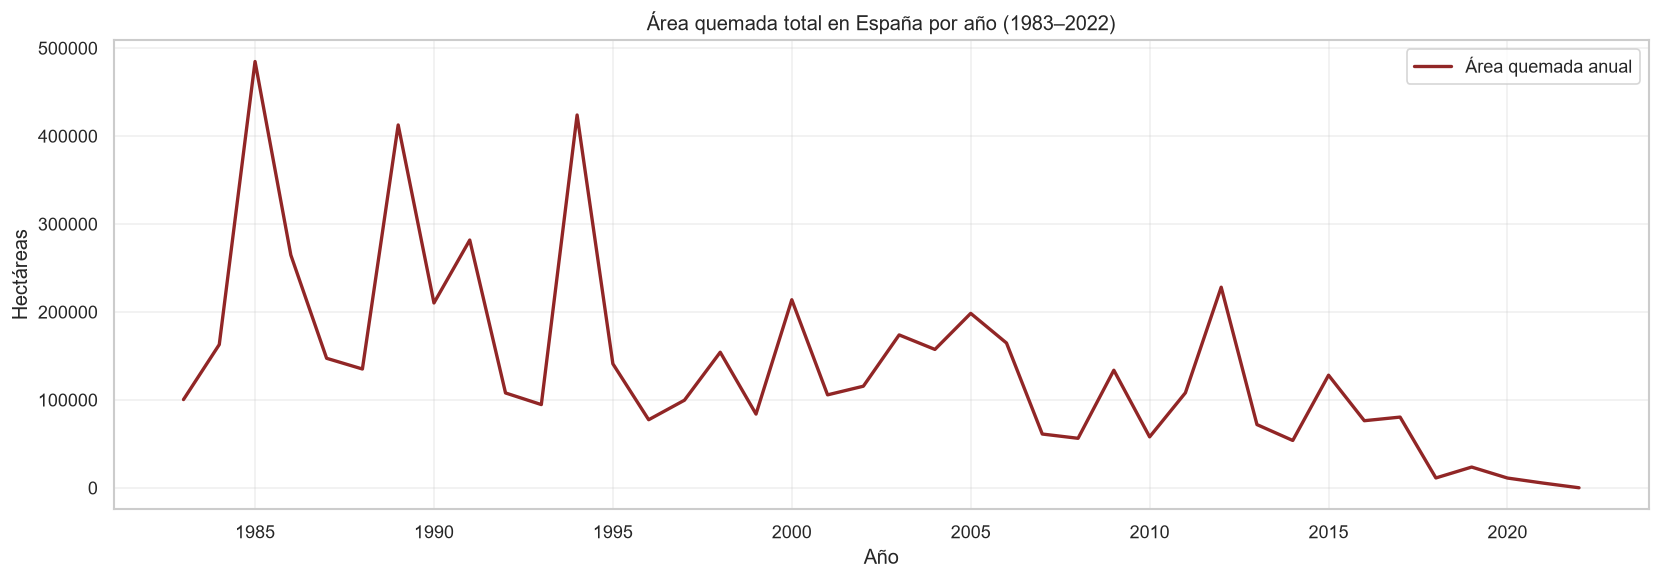

In [ ]:
# Resamplear a anual y sumar el área quemada
ba_anual = ba.resample(time="1YE").sum()
ba_total_anual = ba_anual.sum(dim=["latitude", "longitude"])

# Extraer años y hectáreas quemadas 
años = ba_total_anual.time.dt.year.values
hectareas = ba_total_anual.values

# Configurar figura 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(años, hectareas, color="#912626", linewidth=2, label="Área quemada anual")
ax.set_title("Área quemada total en España por año (1983–2022)")
ax.set_xlabel("Año")
ax.set_ylabel("Hectáreas")
ax.grid(alpha=0.3)
ax.legend()

# Ajustar el layout y guardar la figura
plt.tight_layout()
plt.savefig(FIGURES / "serie_anual_tendencia.png", bbox_inches="tight")
plt.show()

## MAPA HOTSPOTS HISTÓRICOS DE INCENDIOS FORESTALES EN ESPAÑA

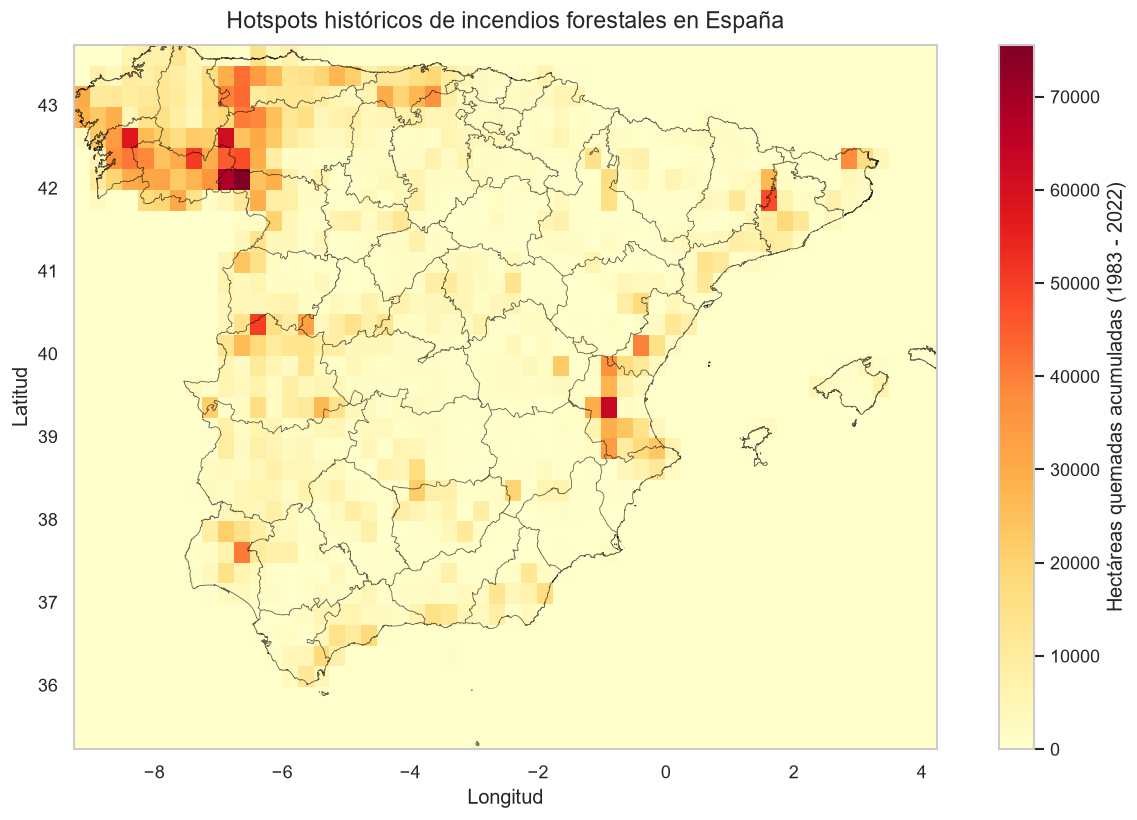

In [ ]:
# Cargar el shapefile provincial
provincias = gpd.read_file(ruta_provincias)

# Reproyectar las provincias filtradas a WGS84 para alinearlas con la cuadrícula de FIRESPAIN
provincias = provincias.to_crs(epsg=4326)

# Calcular el acumulado temºporal del área quemada en Xarray
ba_acumulado = ba.sum(dim="time")

# Configurar figura y graficar
fig, ax = plt.subplots(figsize=(11, 7))

ba_acumulado.plot( # type: ignore
    ax=ax,
    cmap="YlOrRd",
    cbar_kwargs={"label": "Hectáreas quemadas acumuladas (1983 - 2022)"})

provincias.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
    alpha=0.6)

# Títulos y etiquetas de los ejes
ax.set_title("Hotspots históricos de incendios forestales en España", fontsize=14, pad=10)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Guardar imagen
plt.tight_layout()
plt.savefig(FIGURES / "mapa_hotspots.png", bbox_inches="tight")
plt.show()



## FRECUENCIA HISTÓRICA DE INCENDIOS

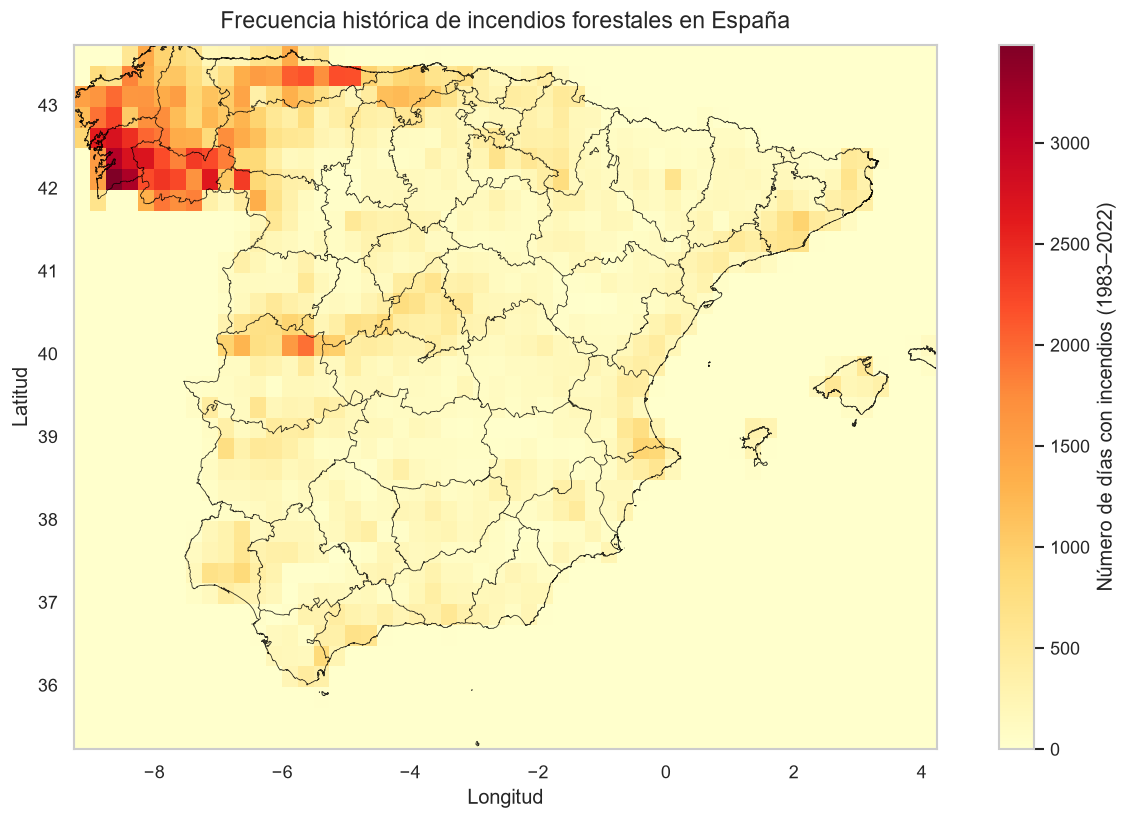

In [ ]:
# Número de días con incendios por celda
dias_incendio = (ba > 0).sum(dim="time")

# Configurar figura
fig, ax = plt.subplots(figsize=(11, 7))

# Mapa de frecuencia
dias_incendio.plot(
    ax=ax,
    cmap="YlOrRd",
    cbar_kwargs={"label": "Número de días con incendios (1983–2022)"}
)

# Superponer límites provinciales
provincias.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8
)

# Títulos y etiquetas
ax.set_title("Frecuencia histórica de incendios forestales en España", fontsize=14, pad=10)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

# Guardar figura
plt.tight_layout()
plt.savefig(FIGURES / "frecuencia_incendios.png", dpi=300, bbox_inches="tight")

plt.show()

## DISTRIBUCIÓN DEL ÁREA QUEMADA DIARIA

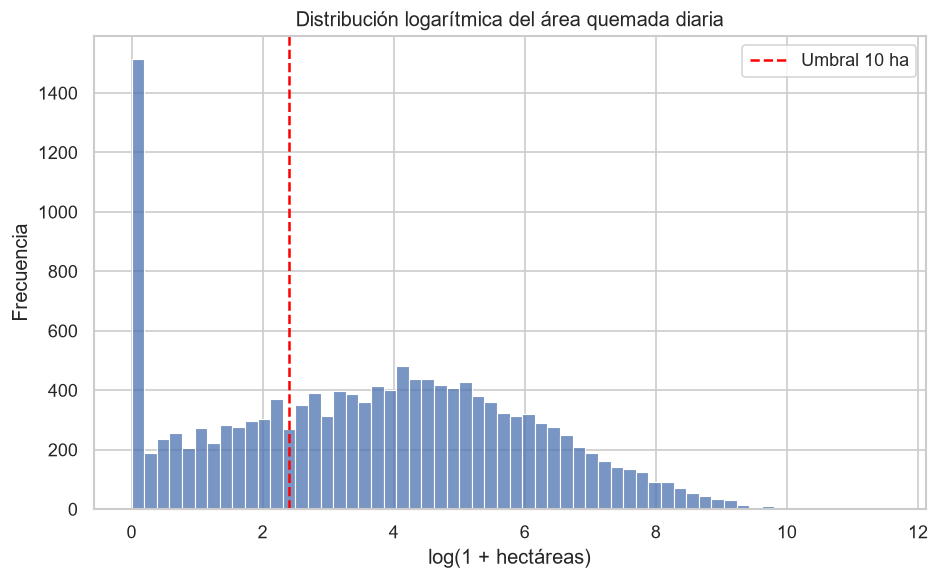

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

# Histograma
sns.histplot(
    np.log1p(ba.sum(dim=["latitude","longitude"])),
    bins=60,
    ax=ax
)

ax.set_title("Distribución logarítmica del área quemada diaria")
ax.set_xlabel("log(1 + hectáreas)")
ax.set_ylabel("Frecuencia")

ax.axvline(
    np.log1p(10),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Umbral 10 ha"
)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "histograma_log.png", bbox_inches="tight")

plt.show()

## ESTACIONALIDAD MENSUAL DEL ÁREA QUEMADA EN ESPAÑA

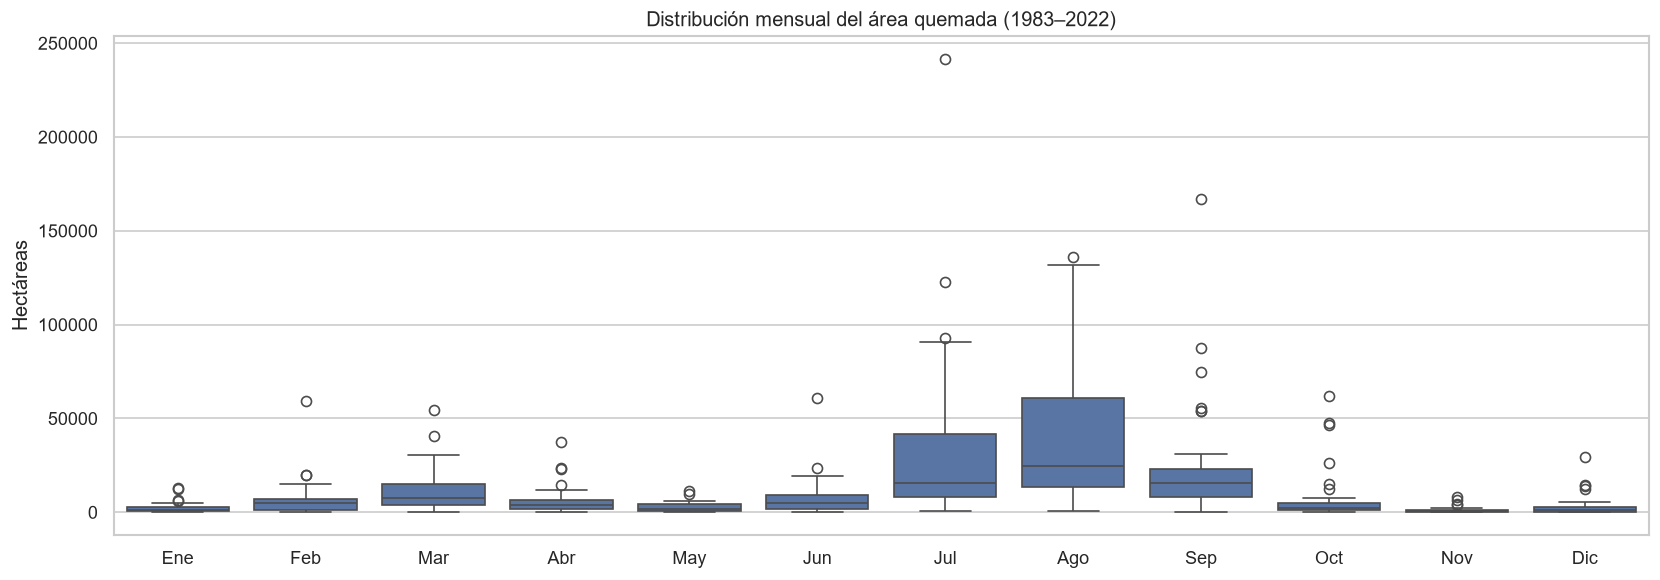

In [ ]:
# Resampleo mensual y suma de área quemada
ba_mensual = (
    ba.resample(time="1ME")
      .sum()
      .sum(dim=["latitude", "longitude"]))

#definir orden de los meses para el boxplot
orden = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
nombres_meses = {i+1: m for i, m in enumerate(orden)}

# Crear un DataFrame para el boxplot
df_mensual = (
    ba_mensual
    .to_dataframe(name="hectareas")
    .reset_index()
    .assign(Mes=lambda df: df["time"].dt.month.map(nombres_meses)))

# Configurar figura y graficar
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_mensual, x="Mes", y="hectareas", order=orden, ax=ax)

# Títulos y etiquetas de los ejes
ax.set_title("Distribución mensual del área quemada (1983–2022)")
ax.set_xlabel("")
ax.set_ylabel("Hectáreas")

# Ajustar el layout y guardar la figura
plt.tight_layout()
plt.savefig(FIGURES / "estacionalidad_boxplot.png", bbox_inches="tight")
plt.show()



In [14]:
# TABLA DE ESTACIONALIDAD MENSUAL DEL ÁREA QUEMADA EN ESPAÑA
# Crear un DataFrame con la media histórica por mes
df_estacionalidad = pd.DataFrame({
    "Mes": orden,
    "Hectareas_Media": (
        ba_mensual
        .groupby("time.month")
        .mean()
        .values
    )})

# Imprimir la tabla de estacionalidad mensual
print("\nMedia histórica por mes:")
print(df_estacionalidad.to_string(index=False))


Media histórica por mes:
Mes  Hectareas_Media
Ene      2207.285156
Feb      6421.519531
Mar     10631.189453
Abr      5980.666504
May      2636.761719
Jun      7654.257812
Jul     32763.570312
Ago     40620.035156
Sep     23429.943359
Oct      7398.601074
Nov      1222.388550
Dic      2978.311768


## DIAGNÓSTICO DE LA PÉRDIDA DE DATOS

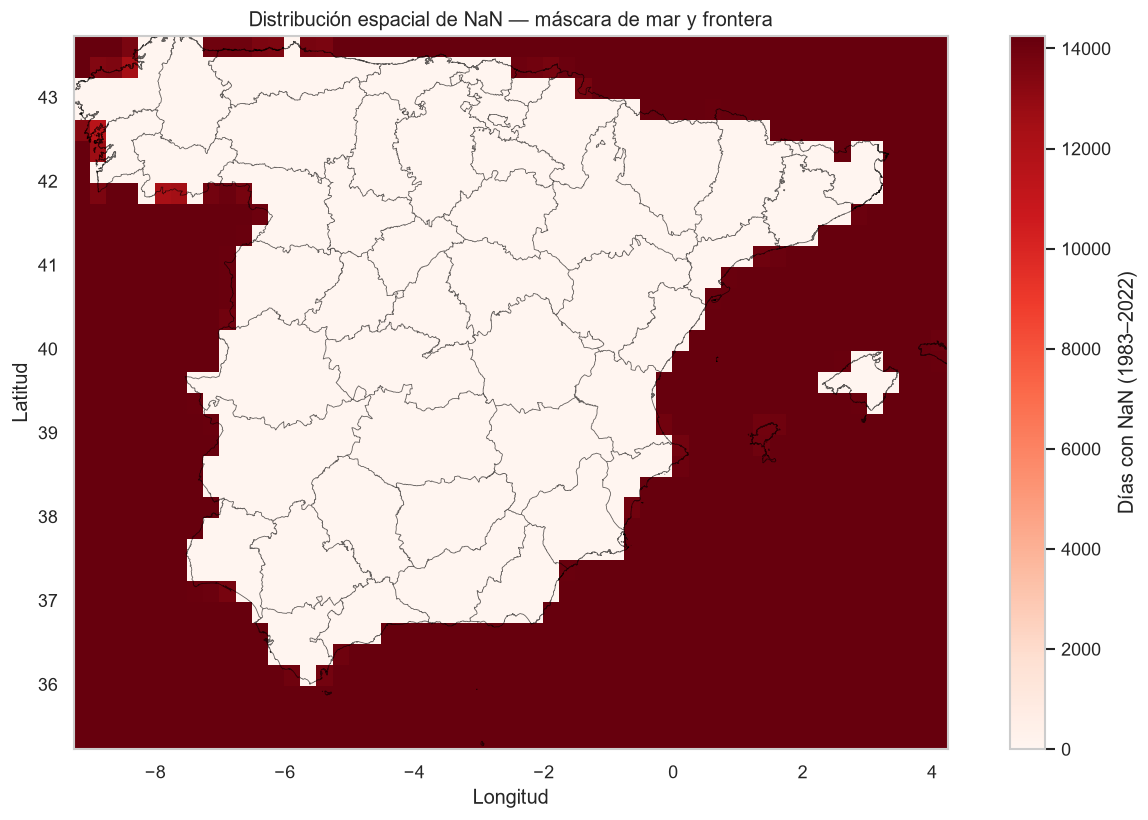

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
nan_por_celda = ba.isnull().sum(dim="time")
nan_por_celda.plot(
    ax=ax,
    cmap="Reds",
    cbar_kwargs={"label": "Días con NaN (1983–2022)"}
)
provincias.plot(
    ax=ax,
    color="black",
    linewidth=0.5,
    alpha=0.6
)

ax.set_title("Distribución espacial de NaN — máscara de mar y frontera")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.savefig(FIGURES / "nan_diagnostico.png", bbox_inches="tight")
plt.show()

# **EDA Soil Water Index**

https://doi.org/10.2909/0929daf7-a0a3-4428-9bc1-cec6691e85d8

## RESUMEN DEL DATASET

In [16]:
# CARGA Y VERIFICACIÓN DEL DATASET ERA5-LAND
era5 = xr.open_dataset(ruta_era5)
print("ERA5-LAND")
print(f"\nPeriodo temporal : desde "f"{str(era5.time.min().values)[:10]} hasta "f"{str(era5.time.max().values)[:10]}")
print(f"Nº de días       : {era5.sizes['time']:,}")
print(f"Latitudes        : {era5.sizes['latitude']}")
print(f"Longitudes       : {era5.sizes['longitude']}")

ERA5-LAND

Periodo temporal : desde 2008-01-01 hasta 2022-01-01
Nº de días       : 5,115
Latitudes        : 34
Longitudes       : 54


In [17]:
# Conversion de temperatura de Kelvin a Celsius para la variable t2m
era5["t2m_c"] = era5["t2m"] - 273.15
era5["tp_mm"] = era5["tp"] * 1000

descripcion = pd.DataFrame({
    "Variable":[
        "t2m_c",
        "tp_mm",
        "swvl1",
        "swvl2",
        "swi_T10_swvl1",
        "swi_T20_swvl1",
        "swi_T40_swvl1"
    ],
    "Descripción":[
        "Temperatura a 2 m",
        "Precipitación total",
        "Humedad suelo (0–7 cm)",
        "Humedad suelo (7–28 cm)",
        "SWI T=10",
        "SWI T=20",
        "SWI T=40"
    ],
    "Unidad":[
        "C",
        "mm",
        "m³/m³",
        "m³/m³",
        "m³/m³",
        "m³/m³",
        "m³/m³"
    ]
})

display(descripcion)

,Variable,Descripción,Unidad
0,t2m_c,Temperatura a 2 m,C
1,tp_mm,Precipitación total,mm
2,swvl1,Humedad suelo (0–7 cm),m³/m³
3,swvl2,Humedad suelo (7–28 cm),m³/m³
4,swi_T10_swvl1,SWI T=10,m³/m³
5,swi_T20_swvl1,SWI T=20,m³/m³
6,swi_T40_swvl1,SWI T=40,m³/m³


## CALIDAD DEL DATASET

In [18]:
variables = [
    "t2m",
    "tp",
    "swvl1",
    "swvl2",
    "swi_T10_swvl1",
    "swi_T20_swvl1",
    "swi_T40_swvl1",
]

resumen = []
for var in variables:
    datos = era5[var]
    resumen.append({
        "Variable": var,
        "Tipo": str(datos.dtype),
        "NaN (%)": float(datos.isnull().mean()) * 100,
        "Mínimo": float(datos.min()),
        "Máximo": float(datos.max()),
        "Media": float(datos.mean()),
        "Desv.Std": float(datos.std())
    })

df_resumen = pd.DataFrame(resumen)
display(df_resumen.round(3))

,Variable,Tipo,NaN (%),Mínimo,Máximo,Media,Desv.Std
0,t2m,float32,37.745,254.969,319.699,291.092,8.327
1,tp,float32,37.745,0.000,0.105,0.001,0.003
2,swvl1,float32,37.745,0.004,0.520,0.264,0.111
3,swvl2,float32,37.745,0.059,0.520,0.273,0.094
4,swi_T10_swvl1,float32,37.745,0.009,0.503,0.264,0.103
5,swi_T20_swvl1,float32,37.745,0.013,0.498,0.264,0.098
6,swi_T40_swvl1,float32,37.745,0.017,0.497,0.264,0.090


In [19]:
# VERIFICACIÓN DE RANGOS FÍSICOS
print("VERIFICACIÓN DE RANGOS\n")
print(f"Temperatura : {era5.t2m_c.min().item():.1f} – {era5.t2m_c.max().item():.1f} C")
print(f"Precipitación : {era5.tp_mm.min().item():.5f} – {era5.tp_mm.max().item():.5f} mm")
print(f"SWVL1 : {era5.swvl1.min().item():.3f} – {era5.swvl1.max().item():.3f} ")
print(f"SWVL2 : {era5.swvl2.min().item():.3f} – {era5.swvl2.max().item():.3f}")
print(f"SWI10 : {era5.swi_T10_swvl1.min().item():.3f} – {era5.swi_T10_swvl1.max().item():.3f}")
print(f"SWI20 : {era5.swi_T20_swvl1.min().item():.3f} – {era5.swi_T20_swvl1.max().item():.3f}")
print(f"SWI40 : {era5.swi_T40_swvl1.min().item():.3f} – {era5.swi_T40_swvl1.max().item():.3f}")

VERIFICACIÓN DE RANGOS

Temperatura : -18.2 – 46.5 C
Precipitación : 0.00000 – 105.12479 mm
SWVL1 : 0.004 – 0.520 
SWVL2 : 0.059 – 0.520
SWI10 : 0.009 – 0.503
SWI20 : 0.013 – 0.498
SWI40 : 0.017 – 0.497


In [20]:
# Identificar el máximo de precipitación
tp_max_idx = era5["tp_mm"].argmax(dim=["time", "latitude", "longitude"])
print(f"Máximo precipitación: {float(era5['tp_mm'].max()):.1f} mm")
print(f"Fecha: {str(era5.time.values[int(tp_max_idx['time'])])[:10]}")
print(f"Lat: {float(era5.latitude[int(tp_max_idx['latitude'])]):.2f}")
print(f"Lon: {float(era5.longitude[int(tp_max_idx['longitude'])]):.2f}")

Máximo precipitación: 105.1 mm
Fecha: 2010-10-10
Lat: 43.10
Lon: -0.39


## ESTACIONALIDAD DE LAS VARIABLES CLIMÁTICAS

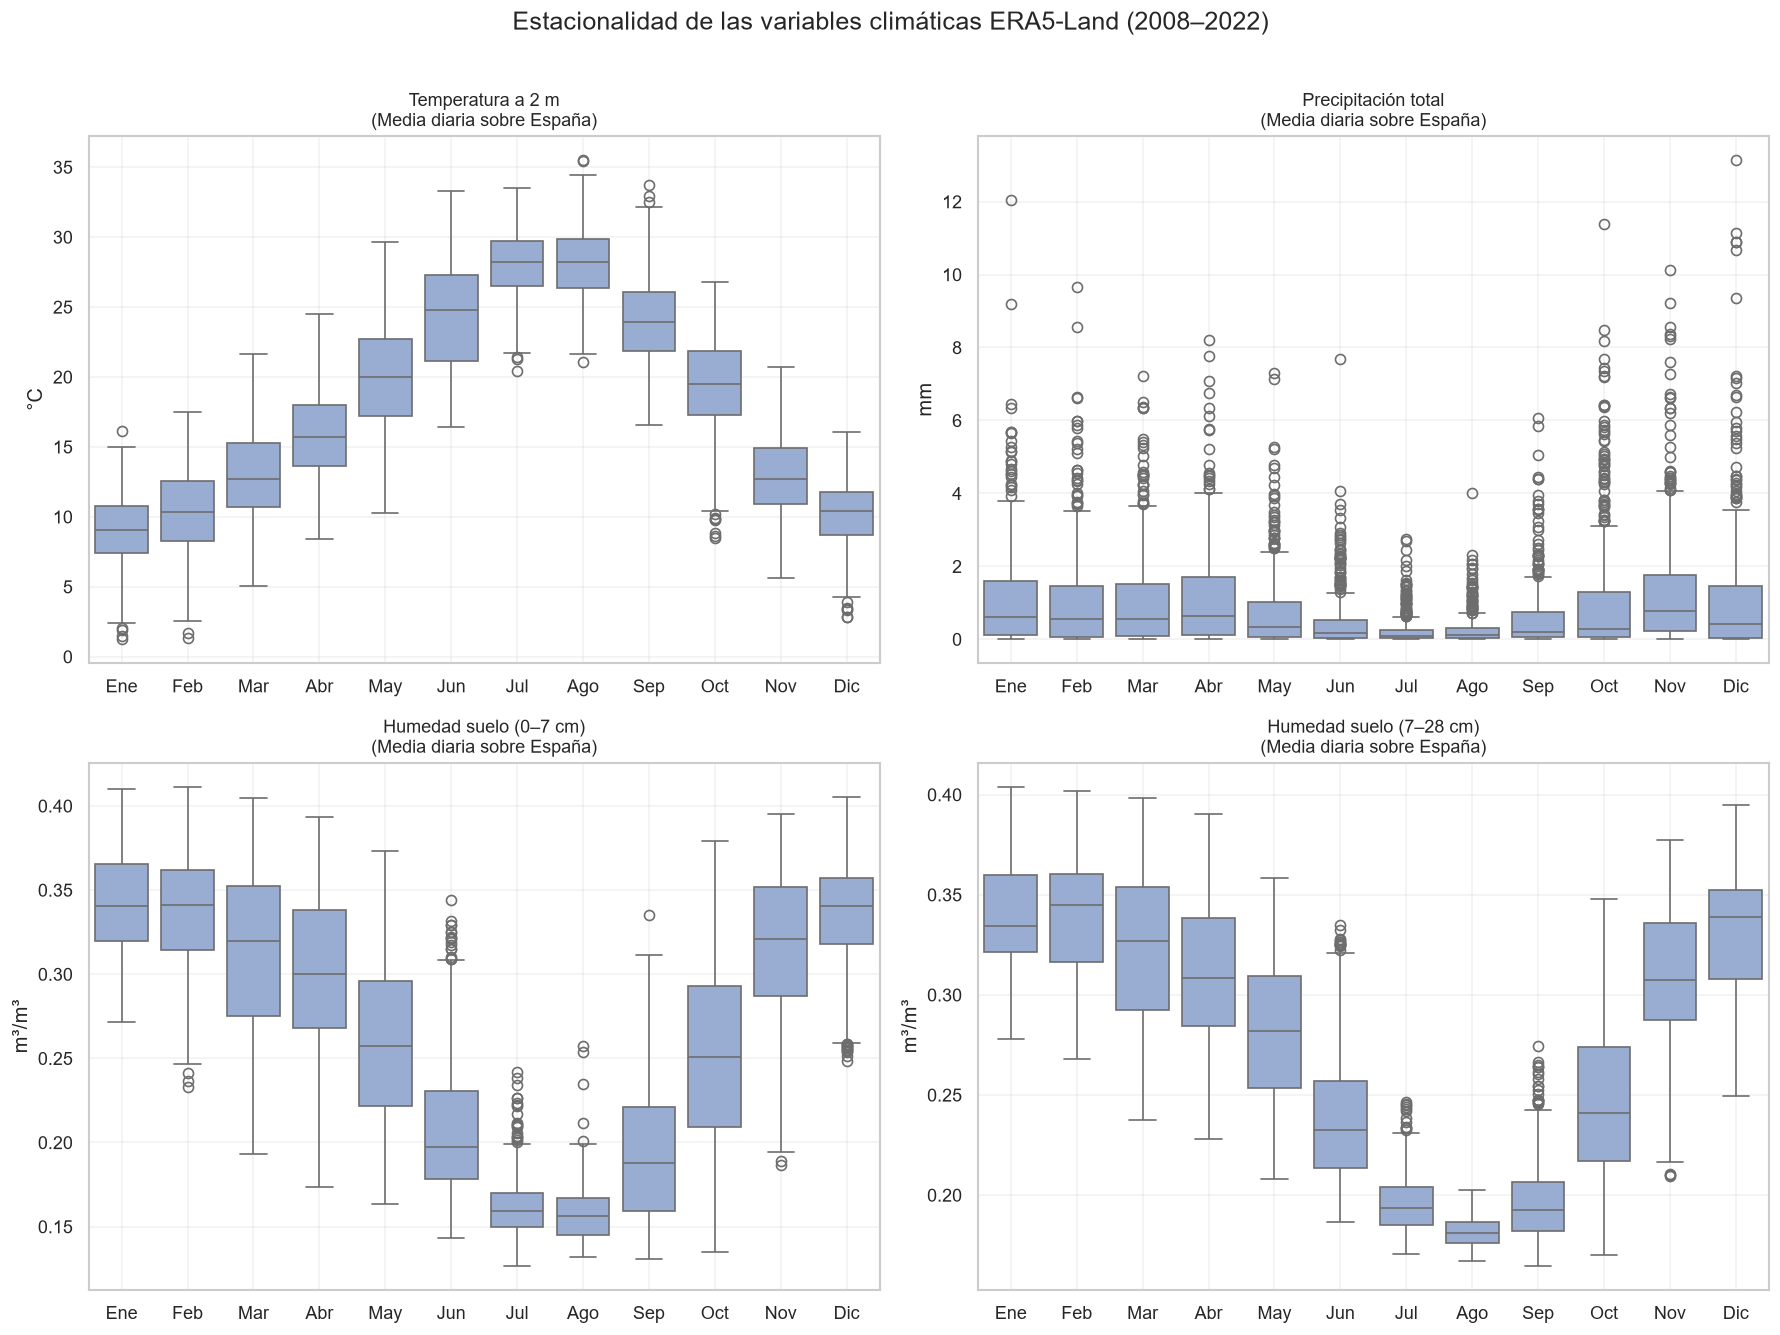

In [21]:
orden = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
meses = {i + 1: m for i, m in enumerate(orden)}

# Variables a representar
vars_plot = {
    "t2m_c": ("Temperatura a 2 m", "°C"),
    "tp_mm": ("Precipitación total", "mm"),
    "swvl1": ("Humedad suelo (0–7 cm)", "m³/m³"),
    "swvl2": ("Humedad suelo (7–28 cm)", "m³/m³")
}
    
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, (var, (titulo, unidad)) in enumerate(vars_plot.items()):
    # Serie diaria media sobre toda España
    serie = era5[var].mean(dim=["latitude", "longitude"])
    df = (
        pd.DataFrame(
            {
                "Fecha": pd.to_datetime(era5.time.values),
                "Valor": serie.values,
            }
        )
        .assign(Mes=lambda d: d["Fecha"].dt.month.map(meses)))

    sns.boxplot(
        data=df,
        x="Mes",
        y="Valor",
        order=orden,
        ax=axes[i],
        color="#8FAADC")

    axes[i].set_title(f"{titulo}\n(Media diaria sobre España)", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(unidad)
    axes[i].grid(alpha=0.25)

plt.suptitle("Estacionalidad de las variables climáticas ERA5-Land (2008–2022)", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "era5_estacionalidad.png", dpi=300, bbox_inches="tight")
plt.show()

## MAPAS DE VARIABLES CLIMATOLÓGICAS

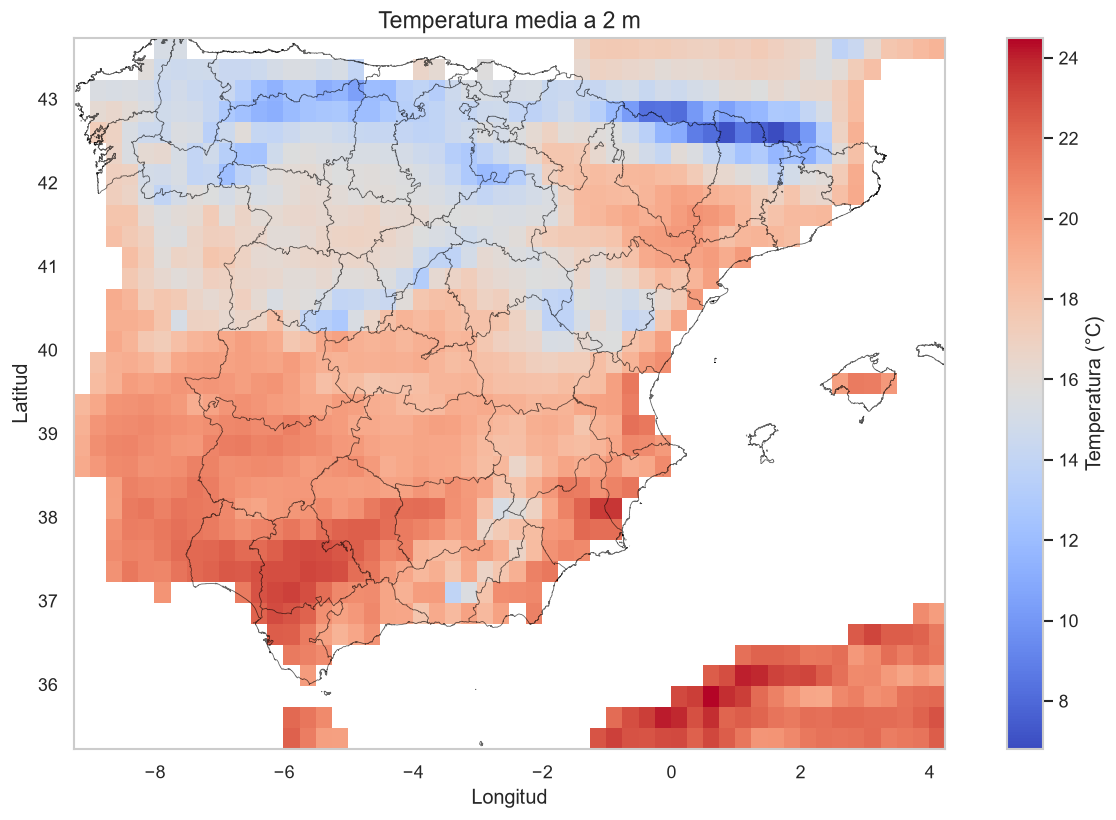

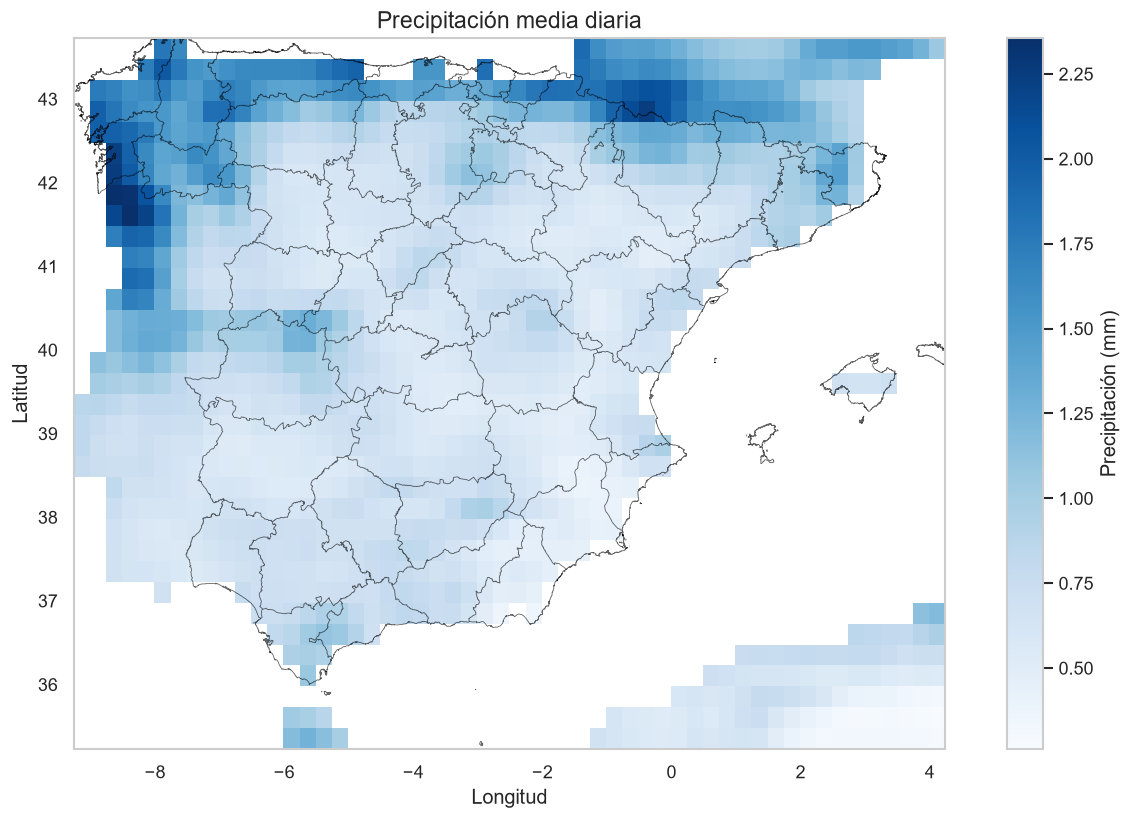

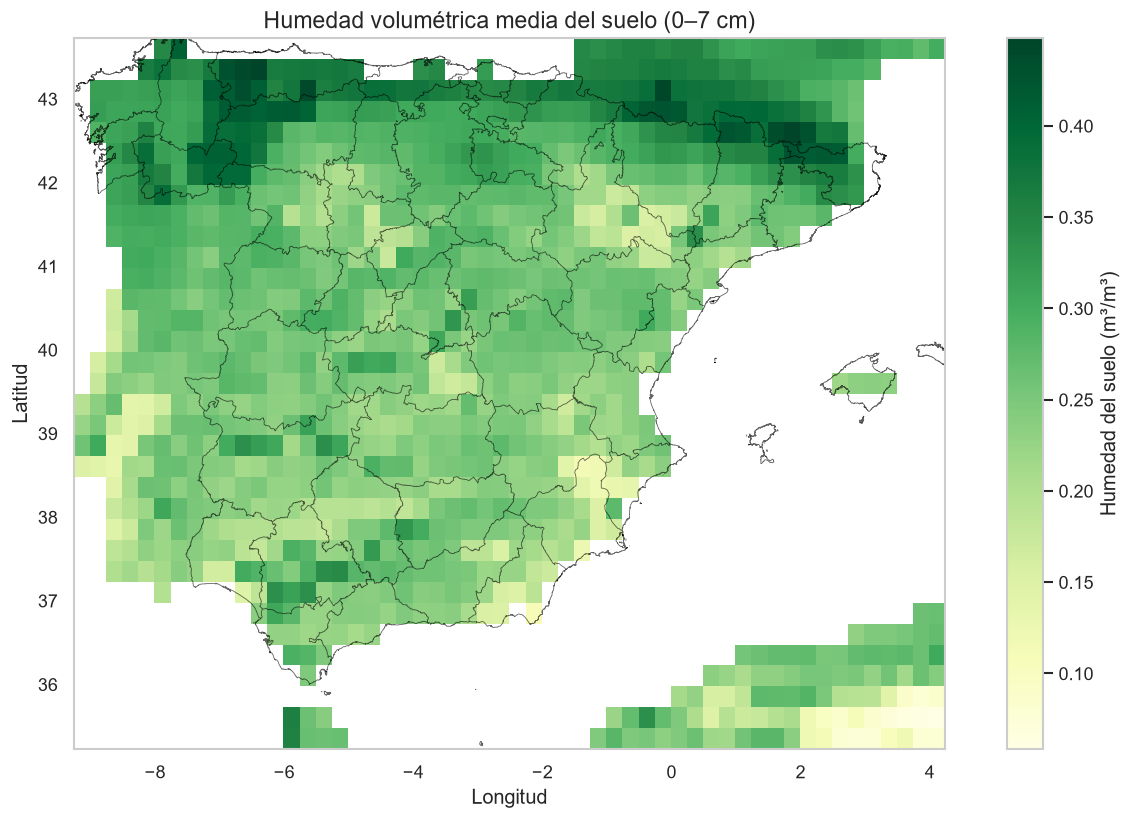

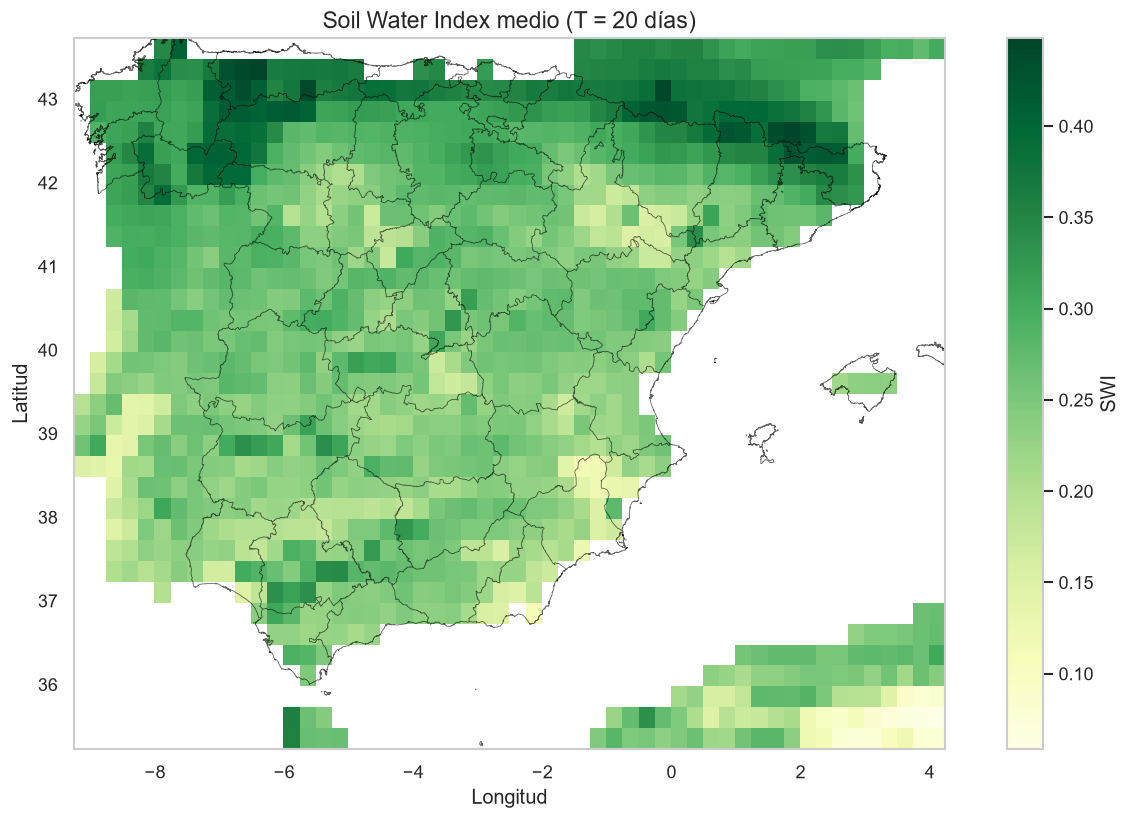

In [22]:
variables = {
    "t2m_c": (
        "Temperatura media a 2 m",
        "Temperatura (°C)",
        "coolwarm",
        "mapa_t2m_media.png"),
    "tp_mm": (
        "Precipitación media diaria",
        "Precipitación (mm)",
        "Blues",
        "mapa_tp_media.png"),
    "swvl1": (
        "Humedad volumétrica media del suelo (0–7 cm)",
        "Humedad del suelo (m³/m³)",
        "YlGn",                
        "mapa_swvl1_media.png"),
    "swi_T20_swvl1": (
        "Soil Water Index medio (T = 20 días)",
        "SWI",
        "YlGn",
        "mapa_swi20_media.png")
}

for var, (titulo, cbar, cmap, nombre) in variables.items():
    media = era5[var].mean(dim="time")
    fig, ax = plt.subplots(figsize=(11, 7))
    media.plot(
        ax=ax,
        cmap=cmap,
        cbar_kwargs={"label": cbar}
    )

    provincias.plot(
        ax=ax,
        color="black",
        linewidth=0.5,
        alpha=0.6
    )

    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

    plt.tight_layout()
    plt.savefig(FIGURES / nombre, dpi=300, bbox_inches="tight")
    plt.show()

## VALIDACIÓN DEL SOIL WATER INDEX (SWI)

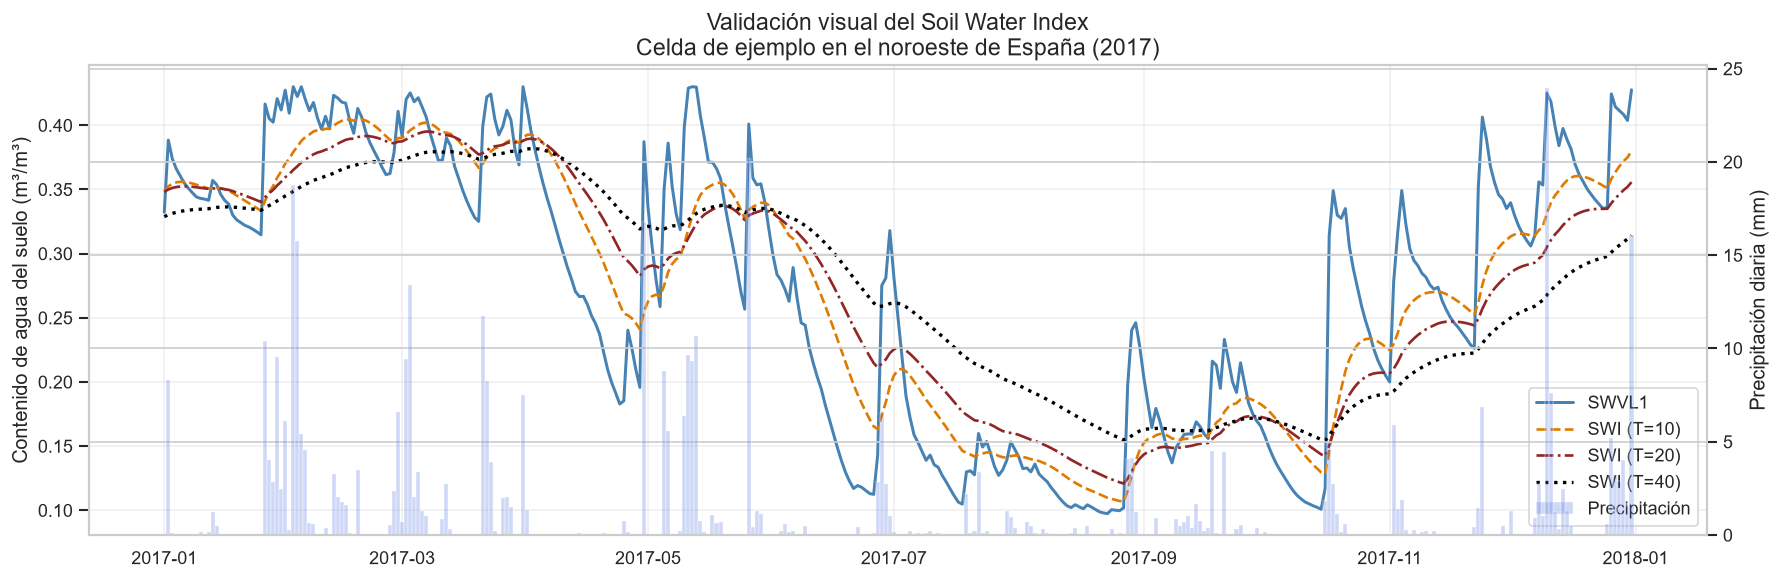

In [23]:
# Celda de ejemplo: noroeste de España
# Se selecciona una ubicación con marcada variabilidad estacional de humedad
# del suelo para ilustrar el efecto del filtro exponencial de Wagner et al. (1999).

lat = 42.75
lon = -8.75

# Extraer series temporales
swvl1 = era5["swvl1"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest")

tp = era5["tp_mm"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest")

swi10 = era5["swi_T10_swvl1"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest")

swi20 = era5["swi_T20_swvl1"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest")

swi40 = era5["swi_T40_swvl1"].sel(
    latitude=lat,
    longitude=lon,
    method="nearest")

# Serie temporal y año representativo
tiempo = pd.to_datetime(era5.time.values)
mask = tiempo.year == 2017


# Figura
fig, ax = plt.subplots(figsize=(15,5))
ax2 = ax.twinx()
ax2.bar(
    tiempo[mask],
    tp.values[mask],
    width=1.0,
    color="royalblue",
    alpha=0.25,
    label="Precipitación"
)

# Humedad original
ax.plot(
    tiempo[mask],
    swvl1.values[mask],
    color="steelblue",
    linewidth=1.8,
    label="SWVL1")
# SWI T10
ax.plot(
    tiempo[mask],
    swi10.values[mask],
    "--",
    color="#E07B00",
    linewidth=1.6,
    label="SWI (T=10)")
# SWI T20
ax.plot(
    tiempo[mask],
    swi20.values[mask],
    "-.",
    color="#912626",
    linewidth=1.6,
    label="SWI (T=20)")
# SWI T40
ax.plot(
    tiempo[mask],
    swi40.values[mask],
    ":",
    color="black",
    linewidth=2,
    label="SWI (T=40)")

ax.set_title(
    "Validación visual del Soil Water Index\n"
    "Celda de ejemplo en el noroeste de España (2017)",
    fontsize=14)

ax.set_xlabel("")
ax.set_ylabel("Contenido de agua del suelo (m³/m³)")
ax2.set_ylabel("Precipitación diaria (mm)")

ax.grid(alpha=0.30)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower right",
    frameon=True)

plt.tight_layout()
plt.savefig(FIGURES / "validacion_swi.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
print("RESUMEN ERA5-LAND\n")
print(f"Período:              2008-01-01 → 2022-01-01")
print(f"Días:                 5,115")
print(f"Resolución:           0.25° (agregado desde 0.1°)")
print(f"Variables climáticas: t2m, tp, swvl1, swvl2")
print(f"SWI derivado:         T=10, T=20, T=40 (Wagner 1999)")
print(f"NaN (%):              37.75% (máscara oceánica)")
print(f"Rango temperatura:    {era5.t2m_c.min().item():.1f} – {era5.t2m_c.max().item():.1f} °C")
print(f"Rango precipitación:  {era5.tp_mm.min().item():.1f} – {era5.tp_mm.max().item():.1f} mm")

RESUMEN ERA5-LAND

Período:              2008-01-01 → 2022-01-01
Días:                 5,115
Resolución:           0.25° (agregado desde 0.1°)
Variables climáticas: t2m, tp, swvl1, swvl2
SWI derivado:         T=10, T=20, T=40 (Wagner 1999)
NaN (%):              37.75% (máscara oceánica)
Rango temperatura:    -18.2 – 46.5 °C
Rango precipitación:  0.0 – 105.1 mm


# **EDA MDT**

## RESUMEN DEL DATASAT

In [25]:
mdt = rxr.open_rasterio(ruta_mdt, masked=True).squeeze()
print(mdt)

<xarray.DataArray (y: 11400, x: 16800)> Size: 766MB
[191520000 values with dtype=float32]
Coordinates:
  * y            (y) float64 91kB 44.5 44.5 44.5 44.5 ... 35.0 35.0 35.0 35.0
  * x            (x) float64 134kB -9.5 -9.499 -9.498 ... 4.497 4.498 4.499
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [26]:
print("MODELO DIGITAL DEL TERRENO (SRTM 90 m)\n")
print(f"CRS:                 {mdt.rio.crs}")
print(f"Resolución:          {mdt.rio.resolution()}")
print(f"Dimensiones:         {dict(zip(mdt.dims, mdt.shape))}")

xmin, ymin, xmax, ymax = mdt.rio.bounds()

print(f"BBOX:")
print(f"   Oeste:            {xmin:.3f}")
print(f"   Este:             {xmax:.3f}")
print(f"   Sur:              {ymin:.3f}")
print(f"   Norte:            {ymax:.3f}")

MODELO DIGITAL DEL TERRENO (SRTM 90 m)

CRS:                 EPSG:4326
Resolución:          (0.000833333333333144, -0.000833333333333144)
Dimensiones:         {'y': 11400, 'x': 16800}
BBOX:
   Oeste:            -9.500
   Este:             4.500
   Sur:              35.000
   Norte:            44.500


## CALIDAD DEL DATASET

In [27]:
# CALIDAD DEL MDT
valores = mdt.values
datos_validos = valores[~np.isnan(valores)]

print("ESTADÍSTICAS")
print(f"Elevación mínima:    {datos_validos.min():.0f} m")
print(f"Elevación máxima:    {datos_validos.max():.0f} m")
print(f"Elevación media:     {datos_validos.mean():.0f} m")
print(f"Desv. estándar:      {datos_validos.std():.0f} m")
print()
print(f"Total píxeles:       {mdt.size:,}")
print(f"Válidos:             {datos_validos.size:,}")
print(f"NaN:                 {np.isnan(valores).sum():,}")
print(f"NaN (%):             {np.isnan(valores).mean()*100:.2f}%")

# DISTRIBUCIÓN DE ELEVACIONES
print("\nPERCENTILES")
for p in [1,5,10,25,50,75,90,95,99]:
    print(f"P{p:02d}: {np.percentile(datos_validos,p):7.0f} m")

ESTADÍSTICAS
Elevación mínima:    -98 m
Elevación máxima:    3460 m
Elevación media:     601 m
Desv. estándar:      415 m

Total píxeles:       191,520,000
Válidos:             117,410,558
NaN:                 74,109,442
NaN (%):             38.70%

PERCENTILES
P01:       7 m
P05:      54 m
P10:     103 m
P25:     262 m
P50:     571 m
P75:     849 m
P90:    1111 m
P95:    1327 m
P99:    1874 m


HISTOGRAMA

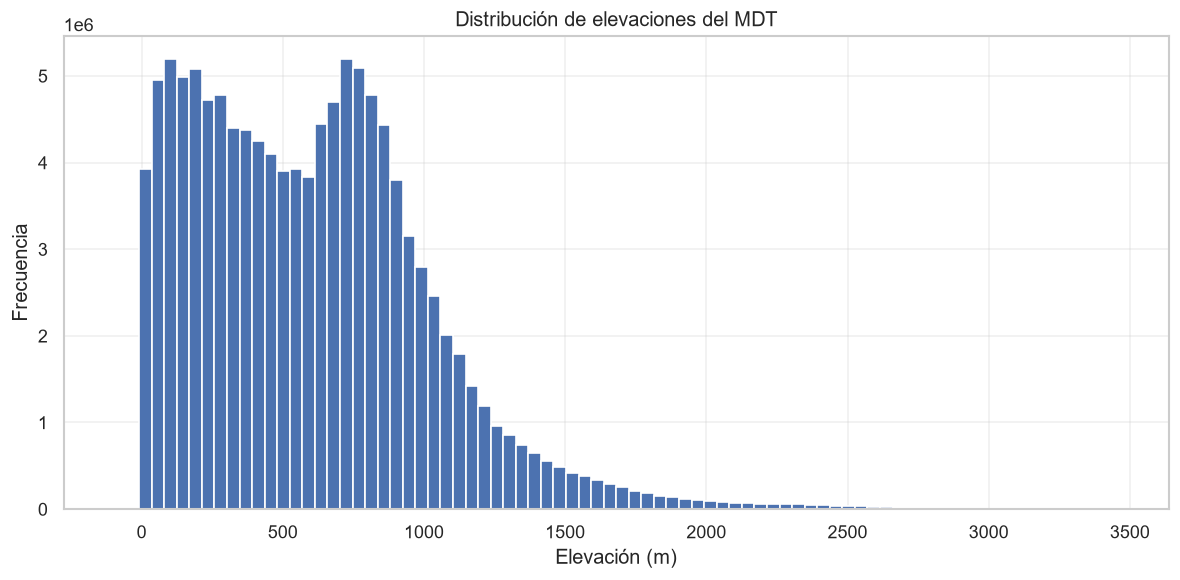

In [28]:
# HISTOGRAMA DE ELEVACIONES
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(datos_validos, bins=80)
ax.set_title("Distribución de elevaciones del MDT")
ax.set_xlabel("Elevación (m)")
ax.set_ylabel("Frecuencia")

ax.grid(alpha=0.30)
plt.tight_layout()
plt.savefig(FIGURES / "mdt_histograma.png", dpi=300)
plt.show()

## MAPA MDT

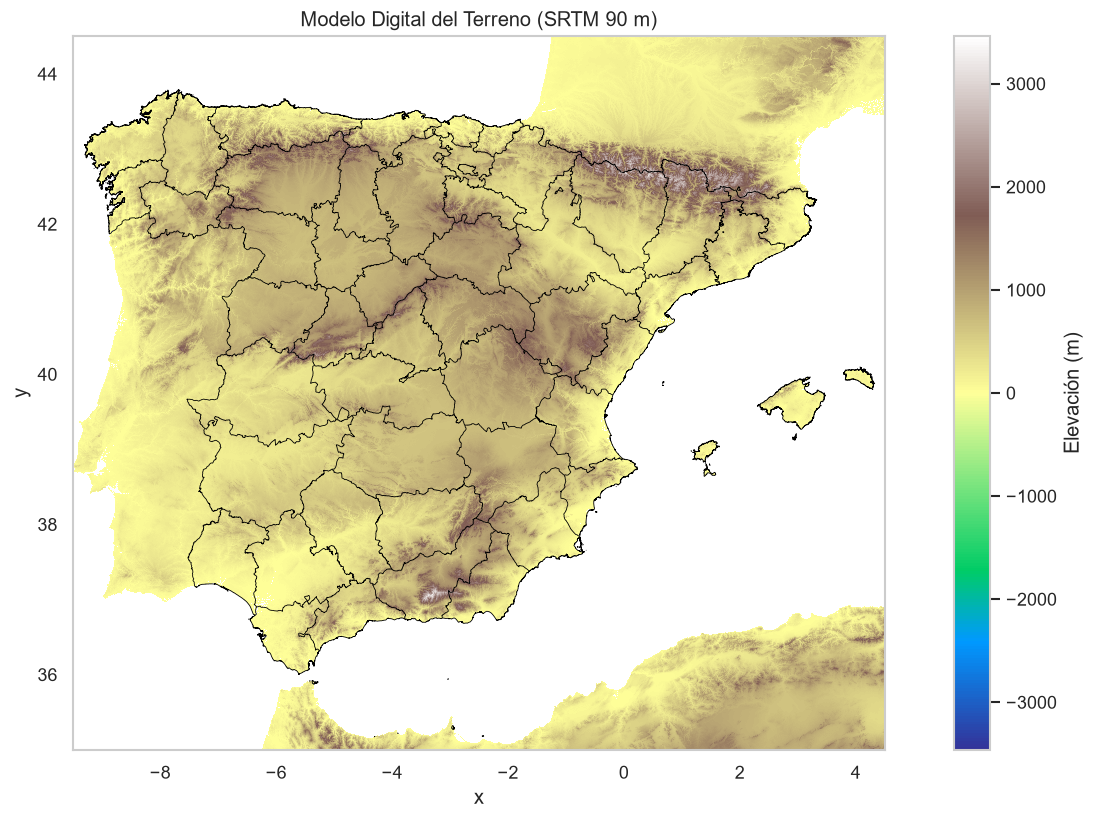

In [29]:
# MAPEO DEL MDT
provincias = gpd.read_file(ruta_provincias)
provincias = provincias.to_crs(mdt.rio.crs)

fig, ax = plt.subplots(figsize=(12,7))

mdt.plot(
    ax=ax,
    cmap="terrain",
    cbar_kwargs={
        "label":"Elevación (m)"
    }
)

provincias.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Modelo Digital del Terreno (SRTM 90 m)")

plt.tight_layout()
plt.savefig(FIGURES / "mdt_spain.png", dpi=300)
plt.show()

RESUMEN

In [34]:
print("RESUMEN MDT")
print(f"Fuente:              SRTM 90m (OpenTopography)")
print(f"CRS:                 {mdt.rio.crs}")
print(f"Resolución nativa:   ~90 m")
print(f"Resolución final:    0.25° (tras agregación en preprocessing)")
print(f"Elevación min/max:   {datos_validos.min():.0f} – {datos_validos.max():.0f} m")
print(f"Elevación media:     {datos_validos.mean():.0f} m")
print(f"NaN:                 {np.isnan(valores).mean()*100:.2f}% (máscara oceánica)")

RESUMEN MDT
Fuente:              SRTM 90m (OpenTopography)
CRS:                 EPSG:4326
Resolución nativa:   ~90 m
Resolución final:    0.25° (tras agregación en preprocessing)
Elevación min/max:   -98 – 3460 m
Elevación media:     601 m
NaN:                 38.70% (máscara oceánica)


# EDA CIVIO

## RESUMEN DEL DATASET

In [ ]:
civio = pd.read_csv(ruta_civio, parse_dates=["fecha"])

print("CIVIO — REGISTRO DE INCENDIOS FORESTALES ESPAÑA")
print(f"\nPeriodo: desde {civio['fecha'].min().date()} hasta {civio['fecha'].max().date()}")
print(f"Total incendios:     {len(civio):,}")
print(f"\nColumnas:")
print(civio.dtypes.to_string())

CIVIO — REGISTRO DE INCENDIOS FORESTALES ESPAÑA

Periodo:             1968-01-01 → 2023-12-08
Total incendios:     292,181

Columnas:
id                          int64
superficie                float64
fecha              datetime64[us]
lat                       float64
lng                       float64
latlng_explicit           float64
idcomunidad                 int64
idprovincia                 int64
idmunicipio                 int64
municipio                     str
causa                       int64
causa_supuesta              int64
causa_desc                  int64
muertos                     int64
heridos                     int64
time_ctrl                   int64
time_ext                    int64
personal                    int64
medios                      int64
gastos                      int64
perdidas                    int64


In [69]:
civio.head(3)

,id,superficie,fecha,lat,lng,latlng_explicit,idcomunidad,idprovincia,idmunicipio,municipio,...,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas,año,mes
0,1968290001,14.0,1968-01-01,NaN,NaN,NaN,4,29,0,INDETERMINADO,...,0,0,0,360,0,0,0,0,1968,1
1,1968430003,3.0,1968-01-03,NaN,NaN,NaN,2,43,0,INDETERMINADO,...,0,0,0,60,0,0,0,0,1968,1
2,1968290006,2.0,1968-01-06,NaN,NaN,NaN,4,29,0,INDETERMINADO,...,0,0,0,120,0,0,0,0,1968,1


## CALIDAD DEL DATASET

In [ ]:
print("CALIDAD DE DATOS\n")

# NaN por columna
nan_pct = civio.isnull().mean() * 100
nan_pct = nan_pct[nan_pct > 0].sort_values(ascending=False)
print("Columnas con valores faltantes:")
print(nan_pct.round(1).to_string())

# Coordenadas
n_total        = len(civio)
n_coord_exacta = int(civio["latlng_explicit"].sum())
n_coord_muni   = n_total - n_coord_exacta

print(f"\nCobertura de coordenadas:")
print(f"  Coordenadas exactas:     {n_coord_exacta:,}  ({n_coord_exacta/n_total*100:.1f}%)")
print(f"  Coordenadas municipio:   {n_coord_muni:,}  ({n_coord_muni/n_total*100:.1f}%)")

# Superficie
print(f"\nSuperficie quemada:")
print(f"  Con dato:   {civio['superficie'].notna().sum():,}")
print(f"  Sin dato:   {civio['superficie'].isna().sum():,}")
print(f"  Media:      {civio['superficie'].mean():.1f} ha")
print(f"  Mediana:    {civio['superficie'].median():.1f} ha")
print(f"  Max:        {civio['superficie'].max():.1f} ha")

CALIDAD DE DATOS

Columnas con valores faltantes:
lat                18.6
lng                18.6
latlng_explicit    18.6

Cobertura de coordenadas:
  Coordenadas exactas:     85,738  (29.3%)
  Coordenadas municipio:   206,443  (70.7%)

Superficie quemada:
  Con dato:   292,181
  Sin dato:   0
  Media:      26.8 ha
  Mediana:    3.5 ha
  Max:        28879.1 ha


## DISTRIBUCIÓN TEMPORAL

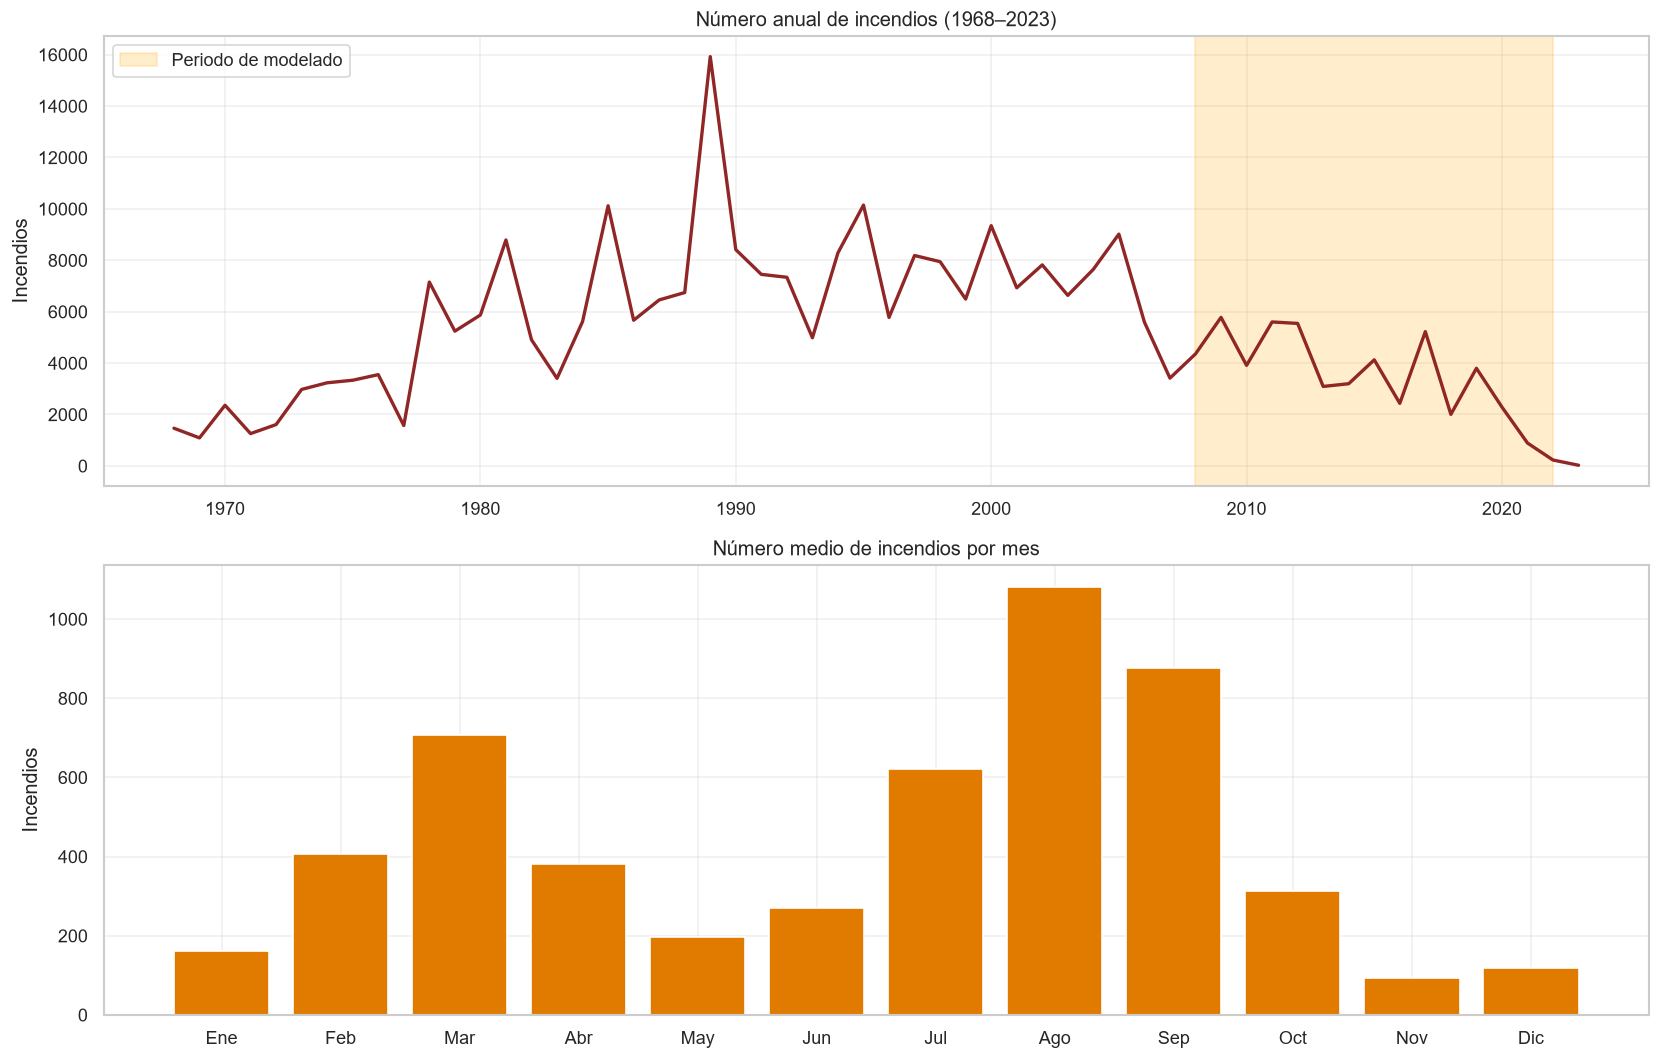

In [ ]:
civio["año"] = civio["fecha"].dt.year
civio["mes"] = civio["fecha"].dt.month

meses = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun", 7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

# Número anual de incendios
incendios_anual = (civio.groupby("año").size())

# Media anual de incendios por mes
incendios_mensual = (civio.groupby(["año","mes"]).size().groupby("mes").mean())

fig, axes = plt.subplots(2, 1, figsize=(14,9))


# Serie temporal anual
axes[0].plot(
    incendios_anual.index,
    incendios_anual.values,
    color="#912626",
    linewidth=2
    )

axes[0].axvspan(
    2008,
    2022,
    color="orange",
    alpha=0.20,
    label="Periodo de modelado"
    )

axes[0].set_title("Número anual de incendios (1968–2023)")
axes[0].set_ylabel("Incendios")
axes[0].grid(alpha=0.3)
axes[0].legend()


# Estacionalidad
axes[1].bar(
    [meses[m] for m in incendios_mensual.index],
    incendios_mensual.values,
    color="#E07B00"
    )

axes[1].set_title("Número medio de incendios por mes")
axes[1].set_ylabel("Incendios")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "civio_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

## DISTRIBUCIÓN ESPACIAL

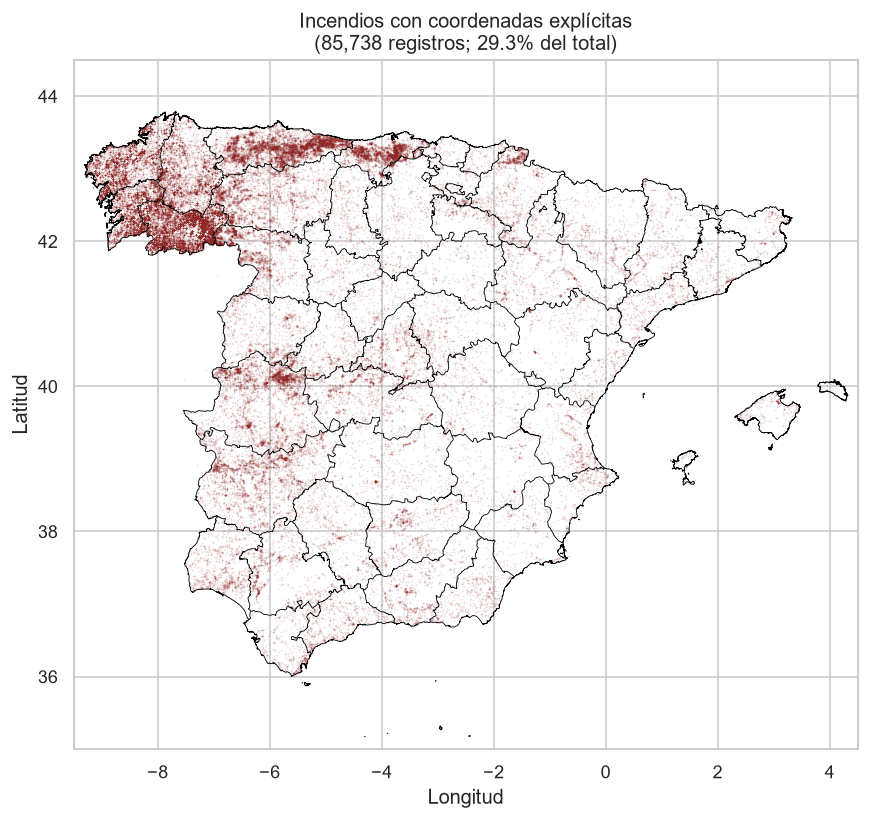

In [ ]:
civio_geo = civio[civio["latlng_explicit"] == 1].copy()

provincias = (gpd.read_file(ruta_provincias).to_crs(epsg=4326))

fig, ax = plt.subplots(figsize=(11,7))

provincias.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.5
    )

ax.scatter(
    civio_geo["lng"],
    civio_geo["lat"],
    s=1,
    alpha=0.15,
    color="#912626",
    linewidths=0
    )

ax.set_xlim(-9.5,4.5)
ax.set_ylim(35.0,44.5)

ax.set_title(
    "Incendios con coordenadas explícitas\n"
    f"({len(civio_geo):,} registros; {len(civio_geo)/len(civio)*100:.1f}% del total)")

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.tight_layout()
plt.savefig(FIGURES/"civio_espacial.png", dpi=300, bbox_inches="tight")
plt.show()

## DISTRIBUCIÓN DE SUPERFICIE QUEMADA

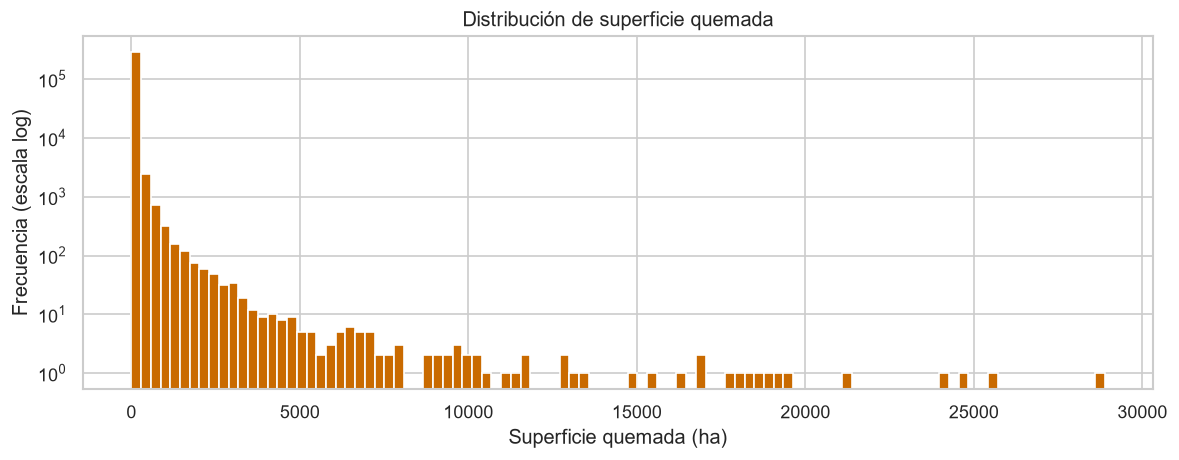

count    292181.00
mean         26.75
std         228.91
min           1.00
25%           1.80
50%           3.50
75%          10.10
max       28879.10
Name: superficie, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

ax.hist(
    civio["superficie"],
    bins=100,
    color="#C96A00"
    )

ax.set_yscale("log")
ax.set_xlabel("Superficie quemada (ha)")
ax.set_ylabel("Frecuencia (escala log)")
ax.set_title("Distribución de superficie quemada")

plt.tight_layout()
plt.savefig(FIGURES/"civio_superficie_hist.png", dpi=300, bbox_inches="tight")
plt.show()

print(civio["superficie"].describe().round(2))

## TAMAÑO DE LOS INCENDIOS

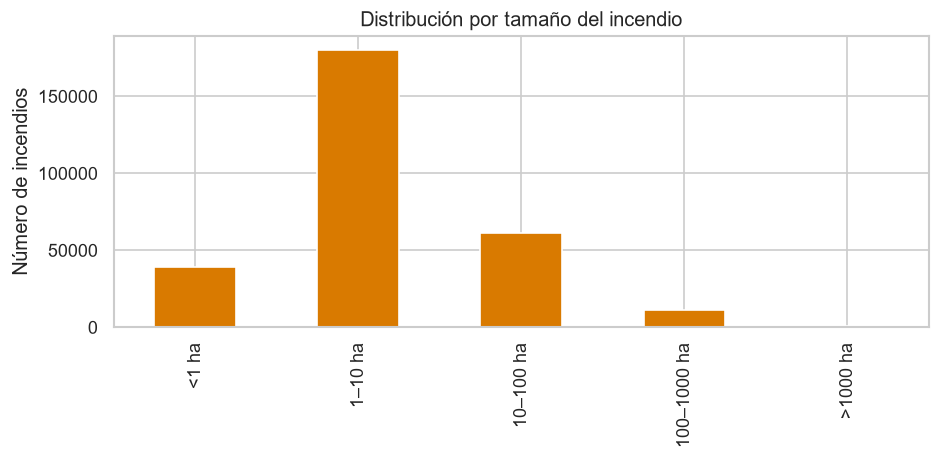

superficie
<1 ha           39066
1–10 ha        179975
10–100 ha       61171
100–1000 ha     11158
>1000 ha          811
Name: count, dtype: int64

Incendios ≥10 ha
superficie
False    211588
True      80593
Name: count, dtype: int64


In [ ]:
bins = [0,1,10,100,1000,np.inf]

labels = ["<1 ha", "1–10 ha", "10–100 ha", "100–1000 ha", ">1000 ha"]

tam = (
    pd.cut(
        civio["superficie"],
        bins=bins,
        labels=labels
    )
    .value_counts()
    .sort_index()
    )

fig, ax = plt.subplots(figsize=(8,4))

tam.plot.bar(ax=ax, color="#D97A00")

ax.set_title("Distribución por tamaño del incendio")
ax.set_ylabel("Número de incendios")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURES/"civio_tamano.png", dpi=300, bbox_inches="tight")
plt.show()

print(tam)
print("\nIncendios ≥10 ha")
print((civio["superficie"]>=10).value_counts())

## CAUSAS DE LOS INCENDIOS

,Incendios
causa,
Desconocida,150524
Reproducción,79292
Negligencia / Accidente,44784
Intencionado,9343
Rayo,6409


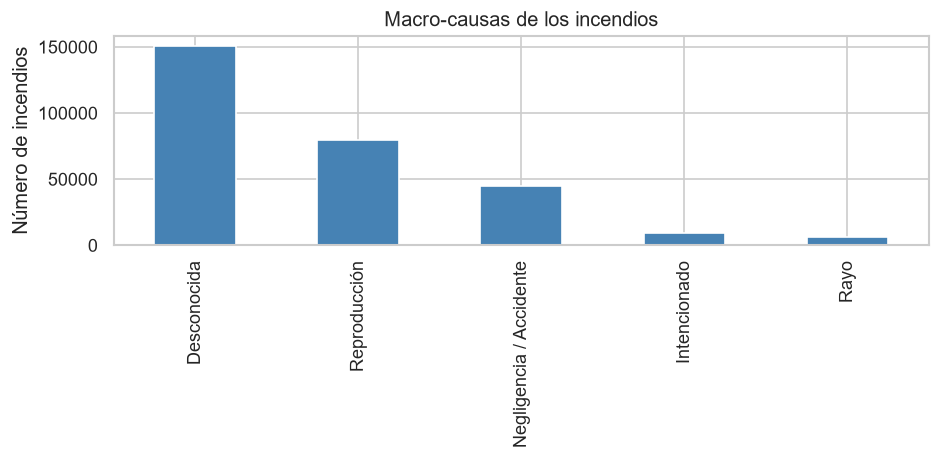

In [ ]:
causas = {
    1:"Rayo",
    2:"Negligencia / Accidente",
    3:"Intencionado",
    4:"Desconocida",
    5:"Reproducción"
    }

causa_freq = (civio["causa"].map(causas).value_counts())
display(causa_freq.to_frame("Incendios"))

fig, ax = plt.subplots(figsize=(8,4))
causa_freq.plot.bar(ax=ax, color="steelblue")
ax.set_title("Macro-causas de los incendios")
ax.set_ylabel("Número de incendios")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURES/"civio_causas.png", dpi=300, bbox_inches="tight")
plt.show()

## RELEVANCIA PARA EL PERÍODO DE MODELADO

In [ ]:
civio_modelo = civio[civio["año"].between(2008,2022)]
civio_historico = civio[civio["año"] < 2008]

print("PERÍODO DE MODELADO")

print(f"Periodo completo (1968–2023):")
print(f"  {len(civio):,} incendios")

print(f"\nPeriodo histórico (<2008):")
print(f"  {len(civio_historico):,} ({len(civio_historico)/len(civio)*100:.1f}%)")

print(f"\nPeriodo del modelo (2008–2022):")
print(f"  {len(civio_modelo):,} ({len(civio_modelo)/len(civio)*100:.1f}%)")


PERÍODO DE MODELADO
Periodo completo (1968–2023):
  292,181 incendios

Periodo histórico (<2008):
  239,709 (82.0%)

Periodo del modelo (2008–2022):
  52,449 (18.0%)


RESUMEN

In [77]:
print("RESUMEN — CIVIO")
print(f"Período: desde {civio['fecha'].min().date()} hasta {civio['fecha'].max().date()}")
print(f"Total incendios: {len(civio):,}")
print(f"Coordenadas exactas: {n_coord_exacta:,} ({n_coord_exacta/n_total*100:.1f}%)")
print(f"Causa desconocida: {civio['causa'].eq(4).sum():,} ({civio['causa'].eq(4).mean()*100:.1f}%)")
print(f"Período histórico (<2008): {len(civio_historico):,} incendios")
print(f"Período modelo (2008-2022): {len(civio_modelo):,} incendios")


RESUMEN — CIVIO
Período: desde 1968-01-01 hasta 2023-12-08
Total incendios: 292,181
Coordenadas exactas: 85,738 (29.3%)
Causa desconocida: 150,524 (51.5%)
Período histórico (<2008): 239,709 incendios
Período modelo (2008-2022): 52,449 incendios
